# University Rankings Analysis — QS vs THE (2024/2025)
This notebook cleans, merges, analyzes, and visualizes the QS and THE world university ranking data.

**Data note:** The source file `Merged_QS_THE_Universities.xlsx` already contains both QS and THE rankings side by side (one row per university), so this notebook cleans and compares them directly rather than merging two separate files.

In [34]:
# Cell 1 — Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully")

Libraries imported successfully


In [35]:
# Cell 2 — Load dataset
df = pd.read_excel("Merged_QS_THE_Universities.xlsx")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (933, 45)


,QS_2025 Rank,QS_2024 Rank,QS_Institution Name,QS_Location,QS_Location Full,QS_Size,QS_Academic Reputation,QS_Employer Reputation,QS_Faculty Student,QS_Citations per Faculty,QS_International Faculty,QS_International Students,QS_International Research Network,QS_Employment Outcomes,QS_Sustainability,QS_QS Overall Score,THE_rank,THE_name,THE_scores_overall,THE_scores_overall_rank,THE_scores_teaching,THE_scores_teaching_rank,Unnamed: 22,THE_scores_research,THE_scores_citations,THE_scores_citations_rank,THE_scores_industry_income,THE_scores_industry_income_rank,THE_scores_international_outlook,THE_scores_international_outlook_rank,THE_record_type,THE_member_level,THE_url,THE_nid,THE_location,THE_stats_number_students,THE_stats_student_staff_ratio,THE_stats_pc_intl_students,THE_stats_female_male_ratio,THE_aliases,THE_subjects_offered,THE_closed,THE_unaccredited,THE_disabled,THE_website_url
0,1,1,Massachusetts Institute of Technology (MIT),US,United States,M,100.0,100.0,100.0,100.0,99.3,86.8,96.0,100.0,99.0,100,3,Massachusetts Institute of Technology,97.9,30,98.6,2,96.2,11,99.7,1,100.0,16,93.8,66,private,0,/world-university-rankings/massachusetts-insti...,471,United States,11085,8.0,0.33,"1 day, 17:59:00",Massachusetts Institute of Technology,"Architecture,Economics & Econometrics,Archaeol...",False,False,False,https://www.timeshighereducation.com/student/r...
1,2,6,Imperial College London,UK,United Kingdom,L,98.5,99.5,98.2,93.9,100.0,99.6,97.4,93.4,99.7,98.5,8,Imperial College London,95.1,80,90.9,12,95.5,12,98.6,8,90.9,157,98.3,6,master_account,0,/world-university-rankings/imperial-college-lo...,472,United Kingdom,20275,11.8,0.61,"1 day, 18:58:00",Imperial College London,"Computer Science,Mechanical & Aerospace Engine...",False,False,False,https://www.timeshighereducation.com/student/r...
2,3,3,University of Oxford,UK,United Kingdom,L,100.0,100.0,100.0,84.8,98.1,97.7,100.0,100.0,85.0,96.9,1,University of Oxford,98.5,10,96.6,5,100.0,2,99.0,5,98.7,77,97.5,14,master_account,0,/world-university-rankings/university-oxford,468,United Kingdom,21750,10.9,0.42,"2 days, 1:51:00",University of Oxford,"Geography,Chemistry,Chemical Engineering,Biolo...",False,False,False,https://www.timeshighereducation.com/student/r...
3,4,4,Harvard University,US,United States,L,100.0,100.0,96.3,100.0,74.1,69.0,99.6,100.0,84.4,96.8,4,Harvard University,97.8,40,97.7,3,99.9,3,99.4,3,84.2,216,90.8,119,private,0,/world-university-rankings/harvard-university,466,United States,20050,9.0,0.25,"2 days, 3:49:00",Harvard University,"Sociology,Architecture,Physics & Astronomy,Psy...",False,False,False,https://www.timeshighereducation.com/student/r...
4,5,2,University of Cambridge,UK,United Kingdom,L,100.0,100.0,100.0,84.6,100.0,94.8,99.3,100.0,84.8,96.7,5,University of Cambridge,97.5,50,95.8,7,100.0,1,98.0,12,87.9,180,97.4,15,master_account,0,/world-university-rankings/university-cambridge,470,United Kingdom,20565,11.5,0.38,"2 days, 0:52:00",University of Cambridge,Politics & International Studies (incl Develop...,False,False,False,https://www.timeshighereducation.com/student/r...


In [36]:
# Cell 3 — Check dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 933 entries, 0 to 932
Data columns (total 45 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   QS_2025 Rank                           933 non-null    object 
 1   QS_2024 Rank                           923 non-null    object 
 2   QS_Institution Name                    933 non-null    str    
 3   QS_Location                            933 non-null    str    
 4   QS_Location Full                       933 non-null    str    
 5   QS_Size                                933 non-null    str    
 6   QS_Academic Reputation                 933 non-null    float64
 7   QS_Employer Reputation                 933 non-null    float64
 8   QS_Faculty Student                     933 non-null    float64
 9   QS_Citations per Faculty               933 non-null    float64
 10  QS_International Faculty               893 non-null    float64
 11  QS_International 

In [37]:
# Cell 4 — Check column names
print(df.columns.tolist())

['QS_2025 Rank', 'QS_2024 Rank', 'QS_Institution Name', 'QS_Location', 'QS_Location Full', 'QS_Size', 'QS_Academic Reputation', 'QS_Employer Reputation', 'QS_Faculty Student', 'QS_Citations per Faculty', 'QS_International Faculty', 'QS_International Students', 'QS_International Research Network', 'QS_Employment Outcomes', 'QS_Sustainability', 'QS_QS Overall Score', 'THE_rank', 'THE_name', 'THE_scores_overall', 'THE_scores_overall_rank', 'THE_scores_teaching', 'THE_scores_teaching_rank', 'Unnamed: 22', 'THE_scores_research', 'THE_scores_citations', 'THE_scores_citations_rank', 'THE_scores_industry_income', 'THE_scores_industry_income_rank', 'THE_scores_international_outlook', 'THE_scores_international_outlook_rank', 'THE_record_type', 'THE_member_level', 'THE_url', 'THE_nid', 'THE_location', 'THE_stats_number_students', 'THE_stats_student_staff_ratio', 'THE_stats_pc_intl_students', 'THE_stats_female_male_ratio', 'THE_aliases', 'THE_subjects_offered', 'THE_closed', 'THE_unaccredited', 'T

In [38]:
# Cell 5 — Standardize column names
df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

print(df.columns.tolist())

['qs_2025_rank', 'qs_2024_rank', 'qs_institution_name', 'qs_location', 'qs_location_full', 'qs_size', 'qs_academic_reputation', 'qs_employer_reputation', 'qs_faculty_student', 'qs_citations_per_faculty', 'qs_international_faculty', 'qs_international_students', 'qs_international_research_network', 'qs_employment_outcomes', 'qs_sustainability', 'qs_qs_overall_score', 'the_rank', 'the_name', 'the_scores_overall', 'the_scores_overall_rank', 'the_scores_teaching', 'the_scores_teaching_rank', 'unnamed_22', 'the_scores_research', 'the_scores_citations', 'the_scores_citations_rank', 'the_scores_industry_income', 'the_scores_industry_income_rank', 'the_scores_international_outlook', 'the_scores_international_outlook_rank', 'the_record_type', 'the_member_level', 'the_url', 'the_nid', 'the_location', 'the_stats_number_students', 'the_stats_student_staff_ratio', 'the_stats_pc_intl_students', 'the_stats_female_male_ratio', 'the_aliases', 'the_subjects_offered', 'the_closed', 'the_unaccredited', 'th

In [39]:
# Cell 6 — Set important column names
# Based on the actual columns in this dataset (from Cell 4/5 output)
QS_NAME_COL   = "qs_institution_name"
QS_RANK_COL   = "qs_2025_rank"
QS_LOC_COL    = "qs_location"

THE_NAME_COL  = "the_name"
THE_RANK_COL  = "the_rank"
THE_LOC_COL   = "the_location"

print("Using QS name/rank:", QS_NAME_COL, QS_RANK_COL)
print("Using THE name/rank:", THE_NAME_COL, THE_RANK_COL)

Using QS name/rank: qs_institution_name qs_2025_rank
Using THE name/rank: the_name the_rank


In [40]:
# Cell 7 — Clean university names
df[QS_NAME_COL] = (
    df[QS_NAME_COL]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df[THE_NAME_COL] = (
    df[THE_NAME_COL]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("University names cleaned successfully.")

University names cleaned successfully.


In [41]:
# Cell 8 — Check records before cleaning
print("Records before cleaning:", len(df))
print("Duplicate Records:", df.duplicated().sum())

print("\nMissing values in key columns:")
display(df[[QS_NAME_COL, QS_RANK_COL, THE_NAME_COL, THE_RANK_COL]].isnull().sum())

Records before cleaning: 933
Duplicate Records: 0

Missing values in key columns:


qs_institution_name    0
qs_2025_rank           0
the_name               0
the_rank               0
dtype: int64

In [42]:
# Cell 9 — Remove duplicate records
before = len(df)
df = df.drop_duplicates().copy()
print("Records before:", before, "| Records after duplicate removal:", len(df))

Records before: 933 | Records after duplicate removal: 933


In [43]:
# Cell 10 — Convert ranking columns to numeric
# QS and THE both publish RANGE ranks for lower-ranked universities
# (e.g. "601-610", "1201\u20131500", "1501+"), plus THE uses "Reporter" for
# institutions that submitted data but weren't ranked. This function
# converts each rank into a usable number by taking the midpoint of any
# range, so every university gets one numeric rank we can plot and compare.

def parse_rank(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip()
    if s.lower() == "reporter":
        return np.nan
    s = s.replace("\u2013", "-").replace("\u2014", "-")  # normalize en/em dashes
    if "+" in s:
        digits = "".join(ch for ch in s if ch.isdigit())
        return float(digits) if digits else np.nan
    if "-" in s:
        parts = [p for p in s.split("-") if p.strip().isdigit()]
        if len(parts) == 2:
            lo, hi = float(parts[0]), float(parts[1])
            return (lo + hi) / 2
    try:
        return float(s)
    except ValueError:
        return np.nan

# Keep the original text (e.g. "601-610") alongside the numeric estimate
df["qs_rank_band"] = df[QS_RANK_COL].astype(str)
df["the_rank_band"] = df[THE_RANK_COL].astype(str)

df["qs_rank_clean"] = df[QS_RANK_COL].apply(parse_rank)
df["the_rank_clean"] = df[THE_RANK_COL].apply(parse_rank)

print(df["qs_rank_clean"].dtype, df["the_rank_clean"].dtype)
display(df[[QS_RANK_COL, "qs_rank_clean", THE_RANK_COL, "the_rank_clean"]].head(10))

float64 float64


,qs_2025_rank,qs_rank_clean,the_rank,the_rank_clean
0,1,1.0,3,3.0
1,2,2.0,8,8.0
2,3,3.0,1,1.0
3,4,4.0,4,4.0
4,5,5.0,5,5.0
5,6,6.0,2,2.0
6,9,9.0,22,22.0
7,11,11.0,16,16.0
8,13,13.0,37,37.0
9,14,14.0,14,14.0


### Note on the merge step
The original workflow (separate QS.csv + THE.csv) required a `pd.merge()` step. This dataset was already merged upstream, so we skip straight to using it as one table — but every downstream cell (rank difference, categories, KPIs, plots) is unchanged.

In [44]:
# Cell 11 — University name column (for downstream display)
df["university_name"] = df[QS_NAME_COL].fillna(df[THE_NAME_COL])

print("University name column created.")
print("Missing names after fallback:", df["university_name"].isnull().sum())

University name column created.
Missing names after fallback: 0


In [45]:
# Cell 12 — Rank difference
df["rank_difference"] = df["the_rank_clean"] - df["qs_rank_clean"]
df["absolute_rank_difference"] = df["rank_difference"].abs()

display(
    df[["university_name", "qs_rank_clean", "the_rank_clean",
        "rank_difference", "absolute_rank_difference"]].head(10)
)

,university_name,qs_rank_clean,the_rank_clean,rank_difference,absolute_rank_difference
0,Massachusetts Institute of Technology (MIT),1.0,3.0,2.0,2.0
1,Imperial College London,2.0,8.0,6.0,6.0
2,University of Oxford,3.0,1.0,-2.0,2.0
3,Harvard University,4.0,4.0,0.0,0.0
4,University of Cambridge,5.0,5.0,0.0,0.0
5,Stanford University,6.0,2.0,-4.0,4.0
6,UCL,9.0,22.0,13.0,13.0
7,University of Pennsylvania,11.0,16.0,5.0,5.0
8,The University of Melbourne,13.0,37.0,24.0,24.0
9,Peking University,14.0,14.0,0.0,0.0


In [46]:
# Cell 13 — Create ranking categories
def rank_category(rank):
    if pd.isna(rank):
        return "Unknown"
    elif rank <= 10:
        return "Top 10"
    elif rank <= 50:
        return "11-50"
    elif rank <= 100:
        return "51-100"
    elif rank <= 500:
        return "101-500"
    else:
        return "Above 500"

df["qs_rank_category"] = df["qs_rank_clean"].apply(rank_category)
df["the_rank_category"] = df["the_rank_clean"].apply(rank_category)

print("QS Ranking Categories:")
display(df["qs_rank_category"].value_counts())

print("THE Ranking Categories:")
display(df["the_rank_category"].value_counts())

QS Ranking Categories:


qs_rank_category
Above 500    573
101-500      284
11-50         35
51-100        34
Top 10         7
Name: count, dtype: int64

THE Ranking Categories:


the_rank_category
Unknown      685
Above 500     97
101-500       75
51-100        38
11-50         30
Top 10         8
Name: count, dtype: int64

In [47]:
# Cell 14 — Compare QS and THE
def ranking_comparison(row):
    qs_rank = row["qs_rank_clean"]
    the_rank = row["the_rank_clean"]

    if pd.isna(qs_rank) or pd.isna(the_rank):
        return "Unavailable"
    elif qs_rank < the_rank:
        return "QS Higher"
    elif qs_rank > the_rank:
        return "THE Higher"
    else:
        return "Same Rank"

df["ranking_comparison"] = df.apply(ranking_comparison, axis=1)

display(df["ranking_comparison"].value_counts())

ranking_comparison
Unavailable    685
QS Higher      164
THE Higher      80
Same Rank        4
Name: count, dtype: int64

In [48]:
# Cell 15 — Check missing values after processing
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0].head(20))

the_website_url                     718
the_rank_clean                      685
absolute_rank_difference            685
rank_difference                     685
the_scores_overall                   53
unnamed_22                           53
the_scores_teaching                  53
the_scores_industry_income           53
the_scores_international_outlook     53
the_scores_citations                 53
the_stats_female_male_ratio          50
qs_international_faculty             40
qs_international_students            19
qs_2024_rank                         10
qs_sustainability                     2
dtype: int64

In [49]:
# Cell 16 — Handle missing values (numeric columns used in analysis)
for col in ["qs_rank_clean", "the_rank_clean", "rank_difference", "absolute_rank_difference"]:
    missing_before = df[col].isnull().sum()
    df[col] = df[col].fillna(df[col].median())
    print(f"{col}: filled {missing_before} missing values with median")

qs_rank_clean: filled 0 missing values with median
the_rank_clean: filled 685 missing values with median
rank_difference: filled 685 missing values with median
absolute_rank_difference: filled 685 missing values with median


In [50]:
# Cell 17 — Final dataset validation
print("Final Number of Records:", len(df))
print("Final Number of Columns:", len(df.columns))
print("Duplicate Records:", df.duplicated().sum())

Final Number of Records: 933
Final Number of Columns: 55
Duplicate Records: 0


In [51]:
# Cell 18 — KPI calculation
total_universities = df["university_name"].nunique()
average_qs_rank = df["qs_rank_clean"].mean()
average_the_rank = df["the_rank_clean"].mean()
average_rank_difference = df["absolute_rank_difference"].mean()
number_of_countries = df[THE_LOC_COL].nunique()

print("========== KPI ANALYSIS ==========")
print("Total Universities:", total_universities)
print("Average QS Rank:", round(average_qs_rank, 2))
print("Average THE Rank:", round(average_the_rank, 2))
print("Average Absolute Rank Difference:", round(average_rank_difference, 2))
print("Number of Countries:", number_of_countries)

========== KPI ANALYSIS ==========
Total Universities: 933
Average QS Rank: 684.55
Average THE Rank: 290.13
Average Absolute Rank Difference: 104.61
Number of Countries: 89


In [52]:
# Cell 19 — KPI table
kpis = {
    "Total Universities": total_universities,
    "Average QS Rank": round(average_qs_rank, 2),
    "Average THE Rank": round(average_the_rank, 2),
    "Average Rank Difference": round(average_rank_difference, 2),
    "Number of Countries": number_of_countries,
}

kpi_table = pd.DataFrame(list(kpis.items()), columns=["KPI", "Value"])
display(kpi_table)

,KPI,Value
0,Total Universities,933.00
1,Average QS Rank,684.55
2,Average THE Rank,290.13
3,Average Rank Difference,104.61
4,Number of Countries,89.00


In [53]:
# Cell 20 — Top 10 QS universities
top_qs = df.sort_values("qs_rank_clean")[["university_name", "qs_rank_clean"]].head(10)
display(top_qs)

,university_name,qs_rank_clean
0,Massachusetts Institute of Technology (MIT),1.0
1,Imperial College London,2.0
2,University of Oxford,3.0
3,Harvard University,4.0
4,University of Cambridge,5.0
5,Stanford University,6.0
6,UCL,9.0
7,University of Pennsylvania,11.0
8,The University of Melbourne,13.0
9,Peking University,14.0


In [54]:
# Cell 21 — Top 10 THE universities
top_the = df.sort_values("the_rank_clean")[["university_name", "the_rank_clean"]].head(10)
display(top_the)

,university_name,the_rank_clean
2,University of Oxford,1.0
5,Stanford University,2.0
0,Massachusetts Institute of Technology (MIT),3.0
3,Harvard University,4.0
4,University of Cambridge,5.0
16,Princeton University,6.0
1,Imperial College London,8.0
17,Yale University,10.0
14,Tsinghua University,12.0
15,University of Chicago,13.0


In [55]:
# Cell 22 — Largest ranking differences
largest_difference = (
    df.sort_values("absolute_rank_difference", ascending=False)
    [["university_name", "qs_rank_clean", "the_rank_clean",
      "rank_difference", "absolute_rank_difference"]]
    .head(10)
)
display(largest_difference)

,university_name,qs_rank_clean,the_rank_clean,rank_difference,absolute_rank_difference
241,L.N. Gumilyov Eurasian National University (ENU),321.0,1501.0,1180.0,1180.0
272,Pontificia Universidad CatÃ³lica del PerÃº,359.0,1501.0,1142.0,1142.0
302,Satbayev University,405.0,1501.0,1096.0,1096.0
332,Nanjing University of Science and Technology,565.0,1501.0,936.0,936.0
424,Universitas Padjadjaran,596.0,1501.0,905.0,905.0
457,De La Salle University,645.5,1501.0,855.5,855.5
485,Universidad Panamericana (UP),695.5,1501.0,805.5,805.5
504,Diponegoro University,725.5,1501.0,775.5,775.5
514,Altai State University,745.5,1501.0,755.5,755.5
538,Kasetsart University,785.5,1501.0,715.5,715.5


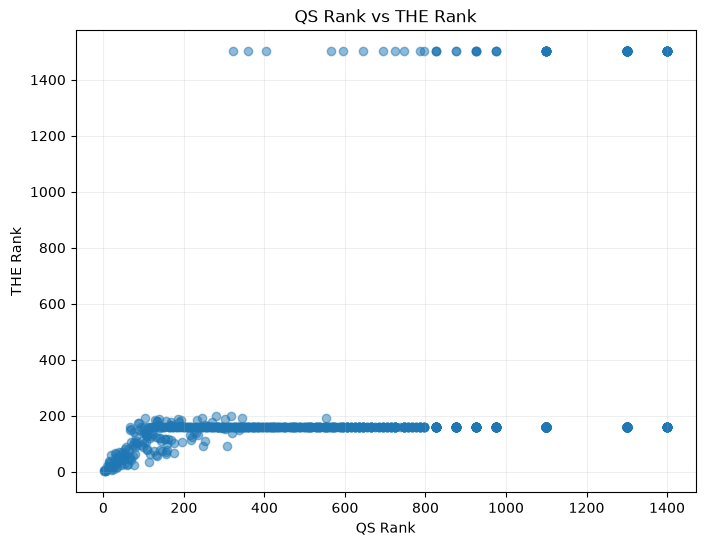

In [56]:
# Cell 23 — QS vs THE scatter plot
plot_data = df.dropna(subset=["qs_rank_clean", "the_rank_clean"])

plt.figure(figsize=(8, 6))
plt.scatter(plot_data["qs_rank_clean"], plot_data["the_rank_clean"], alpha=0.5)
plt.xlabel("QS Rank")
plt.ylabel("THE Rank")
plt.title("QS Rank vs THE Rank")
plt.grid(alpha=0.2)
plt.show()

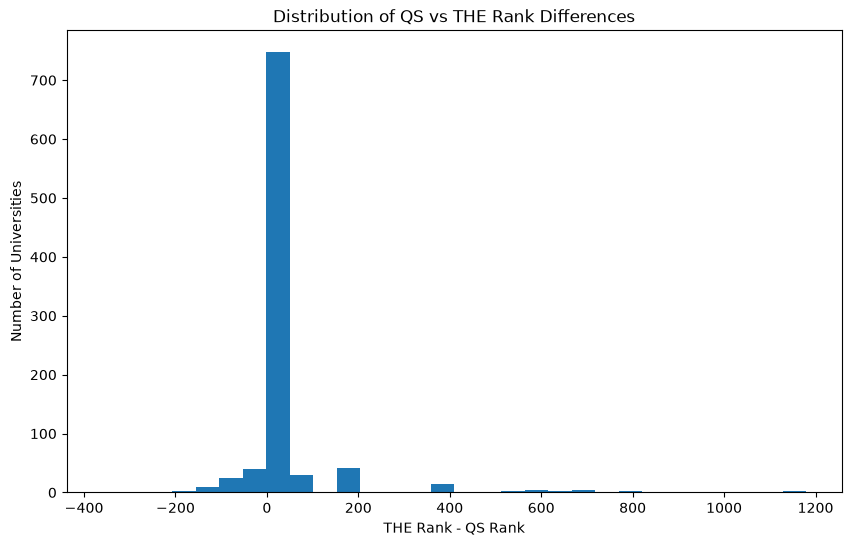

In [57]:
# Cell 24 — Rank difference distribution
plt.figure(figsize=(10, 6))
plt.hist(df["rank_difference"].dropna(), bins=30)
plt.xlabel("THE Rank - QS Rank")
plt.ylabel("Number of Universities")
plt.title("Distribution of QS vs THE Rank Differences")
plt.show()

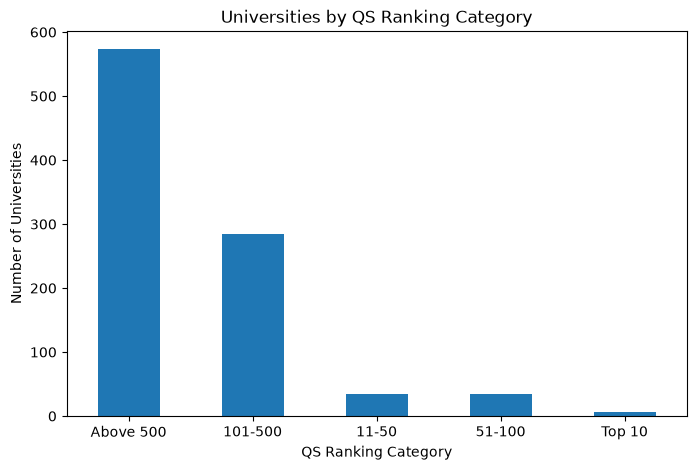

In [58]:
# Cell 25 — QS ranking categories
category_counts = df["qs_rank_category"].value_counts()

plt.figure(figsize=(8, 5))
category_counts.plot(kind="bar")
plt.xlabel("QS Ranking Category")
plt.ylabel("Number of Universities")
plt.title("Universities by QS Ranking Category")
plt.xticks(rotation=0)
plt.show()

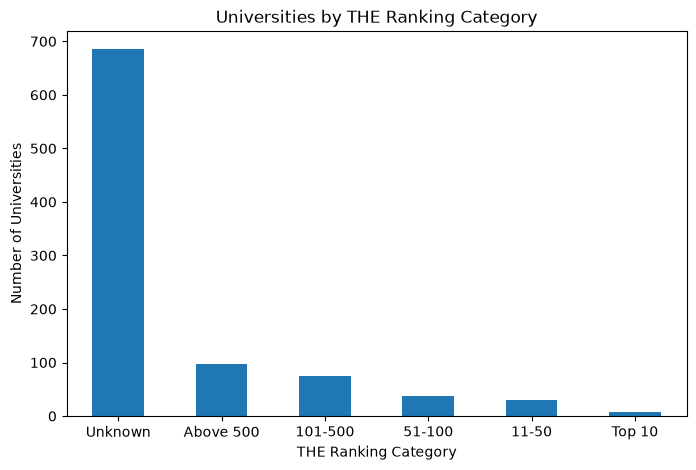

In [59]:
# Cell 26 — THE ranking categories
the_category_counts = df["the_rank_category"].value_counts()

plt.figure(figsize=(8, 5))
the_category_counts.plot(kind="bar")
plt.xlabel("THE Ranking Category")
plt.ylabel("Number of Universities")
plt.title("Universities by THE Ranking Category")
plt.xticks(rotation=0)
plt.show()

In [60]:
# Cell 27 — Correlation
correlation = df[["qs_rank_clean", "the_rank_clean"]].corr()
display(correlation)

,qs_rank_clean,the_rank_clean
qs_rank_clean,1.000000,0.416379
the_rank_clean,0.416379,1.000000


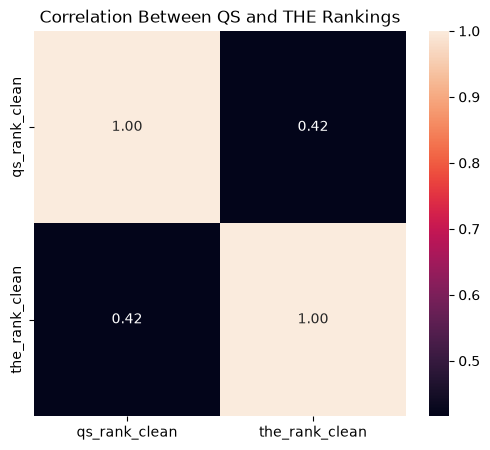

In [61]:
# Cell 28 — Correlation heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, fmt=".2f")
plt.title("Correlation Between QS and THE Rankings")
plt.show()

In [62]:
# Cell 29 — Country analysis
country_counts = df[THE_LOC_COL].value_counts().head(10)
display(country_counts)

the_location
United States         120
United Kingdom         84
Japan                  46
China                  37
Australia              33
South Korea            32
Russian Federation     32
Taiwan                 25
Canada                 24
India                  24
Name: count, dtype: int64

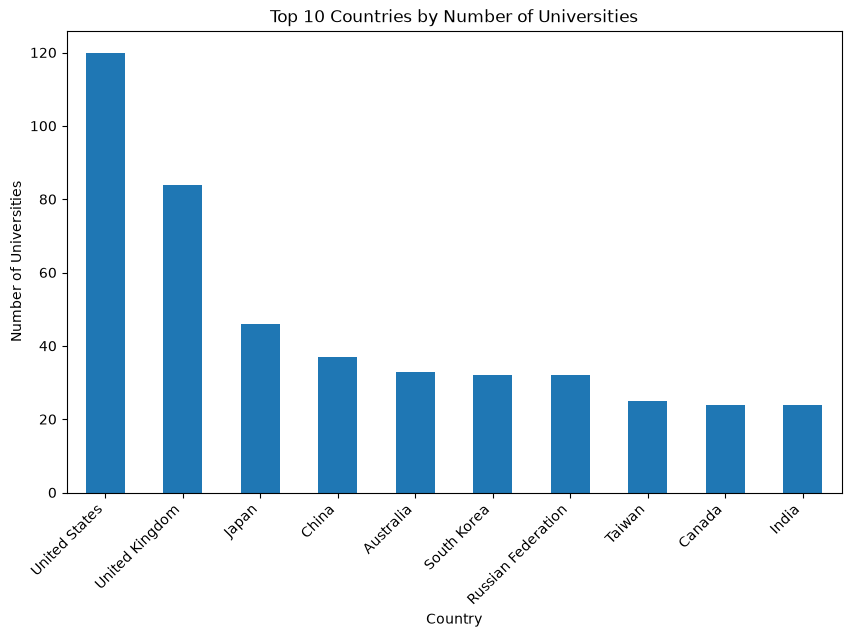

In [63]:
# Cell 30 — Country visualization
plt.figure(figsize=(10, 6))
country_counts.plot(kind="bar")
plt.xlabel("Country")
plt.ylabel("Number of Universities")
plt.title("Top 10 Countries by Number of Universities")
plt.xticks(rotation=45, ha="right")
plt.show()

In [64]:
# Cell 31 — Save final dataset
final_dataset = df.copy()
final_dataset.to_csv("final_cleaned_university_dataset.csv", index=False)

print("Final dataset saved as 'final_cleaned_university_dataset.csv'")
print("Final dataset shape:", final_dataset.shape)

Final dataset saved as 'final_cleaned_university_dataset.csv'
Final dataset shape: (933, 55)


In [65]:
# Cell 32 — Display final dataset
display(final_dataset.head(20))

,qs_2025_rank,qs_2024_rank,qs_institution_name,qs_location,qs_location_full,qs_size,qs_academic_reputation,qs_employer_reputation,qs_faculty_student,qs_citations_per_faculty,qs_international_faculty,qs_international_students,qs_international_research_network,qs_employment_outcomes,qs_sustainability,qs_qs_overall_score,the_rank,the_name,the_scores_overall,the_scores_overall_rank,the_scores_teaching,the_scores_teaching_rank,unnamed_22,the_scores_research,the_scores_citations,the_scores_citations_rank,the_scores_industry_income,the_scores_industry_income_rank,the_scores_international_outlook,the_scores_international_outlook_rank,the_record_type,the_member_level,the_url,the_nid,the_location,the_stats_number_students,the_stats_student_staff_ratio,the_stats_pc_intl_students,the_stats_female_male_ratio,the_aliases,the_subjects_offered,the_closed,the_unaccredited,the_disabled,the_website_url,qs_rank_band,the_rank_band,qs_rank_clean,the_rank_clean,university_name,rank_difference,absolute_rank_difference,qs_rank_category,the_rank_category,ranking_comparison
0,1,1,Massachusetts Institute of Technology (MIT),US,United States,M,100.0,100.0,100.0,100.0,99.3,86.8,96.0,100.0,99.0,100,3,Massachusetts Institute of Technology,97.9,30,98.6,2,96.2,11,99.7,1,100.0,16,93.8,66,private,0,/world-university-rankings/massachusetts-insti...,471,United States,11085,8.0,0.33,"1 day, 17:59:00",Massachusetts Institute of Technology,"Architecture,Economics & Econometrics,Archaeol...",False,False,False,https://www.timeshighereducation.com/student/r...,1,3,1.0,3.0,Massachusetts Institute of Technology (MIT),2.0,2.0,Top 10,Top 10,QS Higher
1,2,6,Imperial College London,UK,United Kingdom,L,98.5,99.5,98.2,93.9,100.0,99.6,97.4,93.4,99.7,98.5,8,Imperial College London,95.1,80,90.9,12,95.5,12,98.6,8,90.9,157,98.3,6,master_account,0,/world-university-rankings/imperial-college-lo...,472,United Kingdom,20275,11.8,0.61,"1 day, 18:58:00",Imperial College London,"Computer Science,Mechanical & Aerospace Engine...",False,False,False,https://www.timeshighereducation.com/student/r...,2,8,2.0,8.0,Imperial College London,6.0,6.0,Top 10,Top 10,QS Higher
2,3,3,University of Oxford,UK,United Kingdom,L,100.0,100.0,100.0,84.8,98.1,97.7,100.0,100.0,85.0,96.9,1,University of Oxford,98.5,10,96.6,5,100.0,2,99.0,5,98.7,77,97.5,14,master_account,0,/world-university-rankings/university-oxford,468,United Kingdom,21750,10.9,0.42,"2 days, 1:51:00",University of Oxford,"Geography,Chemistry,Chemical Engineering,Biolo...",False,False,False,https://www.timeshighereducation.com/student/r...,3,1,3.0,1.0,University of Oxford,-2.0,2.0,Top 10,Top 10,THE Higher
3,4,4,Harvard University,US,United States,L,100.0,100.0,96.3,100.0,74.1,69.0,99.6,100.0,84.4,96.8,4,Harvard University,97.8,40,97.7,3,99.9,3,99.4,3,84.2,216,90.8,119,private,0,/world-university-rankings/harvard-university,466,United States,20050,9.0,0.25,"2 days, 3:49:00",Harvard University,"Sociology,Architecture,Physics & Astronomy,Psy...",False,False,False,https://www.timeshighereducation.com/student/r...,4,4,4.0,4.0,Harvard University,0.0,0.0,Top 10,Top 10,Same Rank
4,5,2,University of Cambridge,UK,United Kingdom,L,100.0,100.0,100.0,84.6,100.0,94.8,99.3,100.0,84.8,96.7,5,University of Cambridge,97.5,50,95.8,7,100.0,1,98.0,12,87.9,180,97.4,15,master_account,0,/world-university-rankings/university-cambridge,470,United Kingdom,20565,11.5,0.38,"2 days, 0:52:00",University of Cambridge,Politics & International Studies (incl Develop...,False,False,False,https://www.timeshighereducation.com/student/r...,5,5,5.0,5.0,University of Cambridge,0.0,0.0,Top 10,Top 10,Same Rank
5,6,5,Stanford University,US,United States,L,100.0,100.0,100.0,99.0,70.3,60.8,96.8,100.0,81.2,96.1,2,Stanford University,98,20,99.0,1,97.8,8,99.6,2,100.0,25,87.0,167,private,0,/world-university-rankings/stanford-university,467,United States,14517,6.4,0.23,"1 day, 23:53:00",Stanford University,"Computer Science,Communication & Media Studies...",False,False,False,NaN,6,2,6.0,2.0,Stanfor

In [66]:
# Cell 33 — Final summary
print("========== PROJECT SUMMARY ==========")
print("Total Records:", len(final_dataset))
print("Total Columns:", len(final_dataset.columns))
print("Duplicate Records:", final_dataset.duplicated().sum())
print("\nProject completed successfully!")

========== PROJECT SUMMARY ==========
Total Records: 933
Total Columns: 55
Duplicate Records: 0

Project completed successfully!
